# PIL을 이용한 이미지 읽어오기

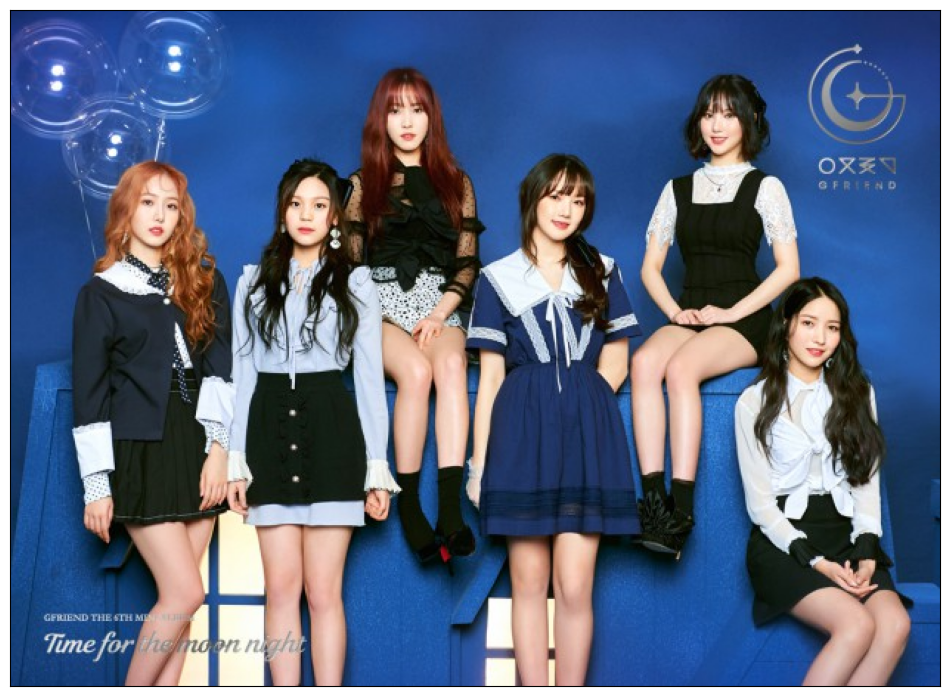

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

PIL_img = Image.open('./data/fig/001.jpg')

plt.figure(figsize = (12, 9))
plt.imshow(PIL_img)
plt.xticks([])
plt.yticks([])
plt.show()

# Scikit Image Package

uv add scikit-image

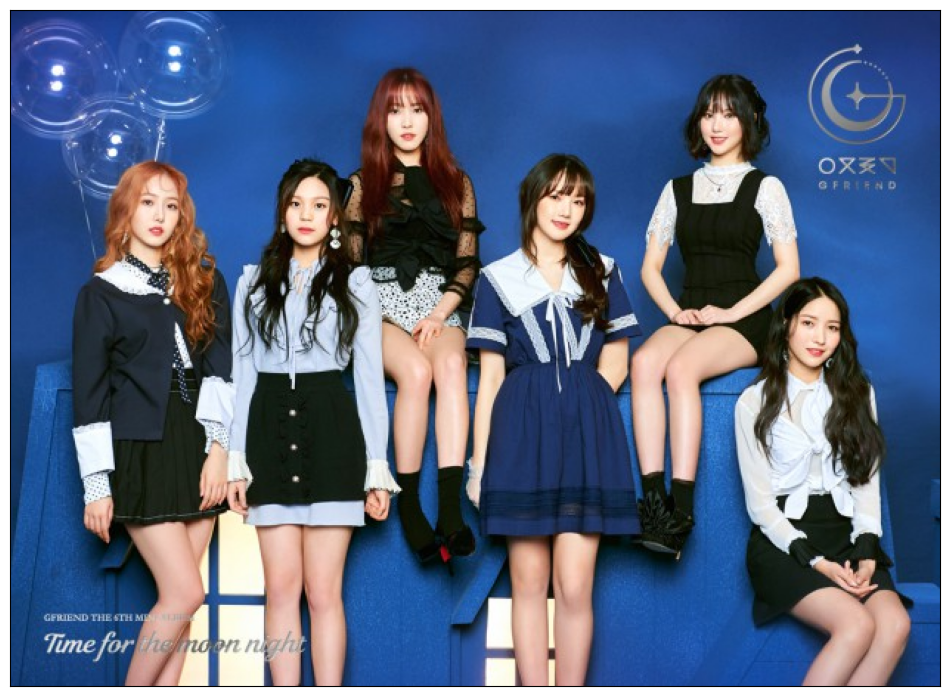

In [9]:
import matplotlib.pyplot as plt
from skimage import io

SK_img = io.imread('./data/fig/001.jpg')

plt.figure(figsize = (12, 9))
plt.imshow(SK_img)
plt.xticks([])
plt.yticks([])
plt.show()

In [10]:
import cv2

cv2.__version__     # '5.0.0'

'5.0.0'

cv2:['ACCESS_FAST', 'ACCESS_MASK', 'ACCESS_READ', 'ACCESS_RW', 'ACCESS_WRITE', 'ADAPTIVE_THRESH_GAUSSIAN_C', 'ADAPTIVE_THRESH_MEAN_C', 'ALGO_HINT_ACCURATE', 'ALGO_HINT_APPROX', 'ALGO_HINT_DEFAULT', 'ALIKED', 'ALIKED_Params', 'ALIKED_create', 'ANNINDEX_DIST_ANGULAR', 'ANNINDEX_DIST_DOTPRODUCT', 'ANNINDEX_DIST_EUCLIDEAN', 'ANNINDEX_DIST_HAMMING', 'ANNINDEX_DIST_MANHATTAN', 'ANNIndex', 'ANNIndex_DIST_ANGULAR', 'ANNIndex_DIST_DOTPRODUCT', 'ANNIndex_DIST_EUCLIDEAN', 'ANNIndex_DIST_HAMMING', 'ANNIndex_DIST_MANHATTAN', 'ANNIndex_create', 'AffineFeature', 'AffineFeature_create', 'Algorithm', 'AlignExposures', 'AlignMTB', 'Animation', 'AsyncArray', 'BFMatcher', 'BFMatcher_create', 'BORDER_CONSTANT', 'BORDER_DEFAULT', 'BORDER_ISOLATED', 'BORDER_REFLECT', 'BORDER_REFLECT101', 'BORDER_REFLECT_101', 'BORDER_REPLICATE', 'BORDER_TRANSPARENT', 'BORDER_WRAP', 'BackgroundSubtractor', 'BackgroundSubtractorKNN', 'BackgroundSubtractorMOG2', 'CALIB_CB_ACCURACY', 'CALIB_CB_ADAPTIVE_THRESH', 'CALIB_CB_ASYMMET

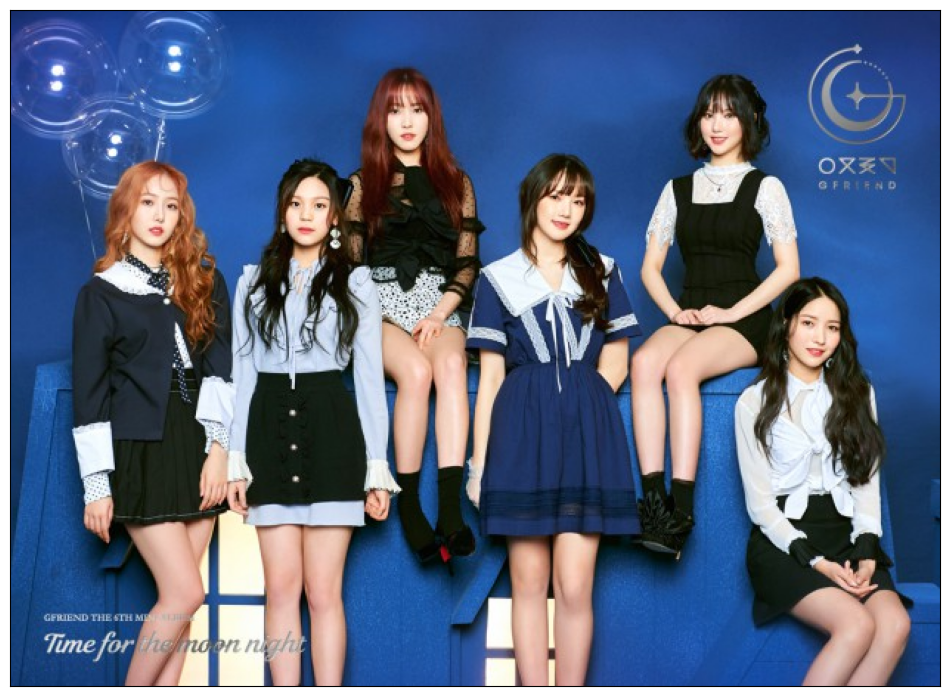

In [11]:
import matplotlib.pyplot as plt
import cv2

print(f'cv2:{dir(cv2)}')
CV_BGR = cv2.imread('./data/fig/001.jpg')
RGB_img = cv2.cvtColor(CV_BGR, cv2.COLOR_BGR2RGB)
print(f'CV_BGR : {dir(CV_BGR)}')
# cv2는 기본적으로 BGR로 읽어옴.

plt.figure(figsize = (12, 9))
plt.imshow(RGB_img)
plt.xticks([])
plt.yticks([])
plt.show()

In [12]:
import cv2
import numpy as np

# 테스트용 간단한 이미지 직접 생성
# 3x4 크기의 컬러 이미지 (BGR)
img = np.array([
    [[255, 0, 0],   [0, 255, 0],   [0, 0, 255],   [255, 255, 0]],
    [[0, 255, 255], [255, 0, 255], [128, 128, 0], [0, 128, 255]],
    [[50, 100, 150],[200, 150, 100],[30, 200, 30], [100, 50, 200]]
], dtype=np.uint8)

print('=== 이미지 배열 기본 정보 ===')
print(f'shape (높이x너비x채널): {img.shape}')  # (3, 4, 3)
print(f'dtype (데이터 타입)   : {img.dtype}')    # uint8
print(f'size  (전체 픽셀 수)  : {img.size}')     # 36
print(f'ndim  (차원 수)       : {img.ndim}')     # 3

# 채널 분리
B, G, R = cv2.split(img)  # 또는 img[:,:,0], img[:,:,1], img[:,:,2]
print(f'\nBlue 채널:\n{B}')
print(f'Green 채널:\n{G}')
print(f'Red 채널:\n{R}')

# 특정 픽셀 값 접근
px = img[0, 0]  # 0행 0열 픽셀
print(f'\n[0,0] 픽셀 BGR: {px}')  # [255 0 0] -> 파란색

# 특정 채널 값만 접근
print(f'[1,2] 픽셀 B채널: {img[1,2,0]}')  # B값만

# 영역(ROI) 선택
roi = img[0:2, 1:3]  # 0~1행, 1~2열 영역
print(f'\nROI shape: {roi.shape}')  # (2, 2, 3)

# 채널 병합
merged = cv2.merge([B, G, R])
print(f'채널 병합 후 shape: {merged.shape}')  # (3, 4, 3)

# float32로 정규화 (딥러닝 전처리 시 사용)
img_float = img.astype(np.float32) / 255.0
print(f'float32 범위: [{img_float.min():.3f}, {img_float.max():.3f}]')


=== 이미지 배열 기본 정보 ===
shape (높이x너비x채널): (3, 4, 3)
dtype (데이터 타입)   : uint8
size  (전체 픽셀 수)  : 36
ndim  (차원 수)       : 3

Blue 채널:
[[255   0   0 255]
 [  0 255 128   0]
 [ 50 200  30 100]]
Green 채널:
[[  0 255   0 255]
 [255   0 128 128]
 [100 150 200  50]]
Red 채널:
[[  0   0 255   0]
 [255 255   0 255]
 [150 100  30 200]]

[0,0] 픽셀 BGR: [255   0   0]
[1,2] 픽셀 B채널: 128

ROI shape: (2, 2, 3)
채널 병합 후 shape: (3, 4, 3)
float32 범위: [0.000, 1.000]


In [13]:
import cv2
import sys

#img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_GRAYSCALE)
img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)


if img is None:
    print("Image read failed")
    sys.exit()

print(type(img)) # class numpy
print(img.shape) # bgr (rgb x)
print(img.dtype)
print(img)

cv2.waitKey(0) # ms
cv2.destroyAllWindows()

cv2.imshow('Lenna', img)

<class 'numpy.ndarray'>
(500, 500, 3)
uint8
[[[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[124 137 226]
  [125 137 225]
  [133 136 222]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 ...

 [[ 59  17  83]
  [ 59  18  84]
  [ 57  26  92]
  ...
  [ 84  72 173]
  [ 76  68 171]
  [ 79  61 176]]

 [[ 57  21  81]
  [ 57  22  82]
  [ 61  31  95]
  ...
  [ 78  69 178]
  [ 80  70 180]
  [ 80  73 184]]

 [[ 56  21  81]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 78  69 178]
  [ 81  71 181]
  [ 81  74 185]]]


In [14]:

# img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_GRAYSCALE)

# if img is None:
#     print("Image read failed")
#     sys.exit()

# print(type(img)) # class numpy
# print(img.shape) # bgr (rgb x)
# print(img.dtype)

# # # cv2_imshow(img)
# cv2.imshow("dog", img)

# cv2.waitKey(0) # ms
# cv2.destroyAllWindows()


cv2.namedWindow(winname, flags = None) -> None

winname: 창 이름
flags:
cv2.WINDOW_NORMAL: 영상크기를 창 크기에 맞게 지정
cv2.WINDOW_AUTOSIZE: 창크기를 영상 크기에 맞게 변경

cv2.imwrite(filename, mat) -> None
filename: 저장할 이름
mat: numpy.ndarray (default = uint8)

uint16, int32의 경우 255로 나누어서 출력
float32, float64의 경우 0 ~ 1로 만든 후 행렬값에 255를 곱해서 출력

In [15]:
## cv2.namedWindow()
img = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

print("width = {}, height = {}".format(
    img.shape[1], img.shape[0]))

# img_resize = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))

if img is None:
    print("Image read failed")
    sys.exit()

## cv2.WINDOW_AUTOSIZE: 창의 크기를 영상에 맞춤
# cv2.namedWindow("Dog", cv2.WINDOW_AUTOSIZE)

cv2.namedWindow("Dog", cv2.WINDOW_NORMAL)
cv2.imshow("Dog", img)
# cv2.imshow("Dog_resize", img_resize)

cv2.waitKey(0)
cv2.destroyAllWindows()
# cv2.waitKey(1) # mac

width = 500, height = 500


# 키보드 입력대기

In [16]:
img  = cv2.imread("./data/fig/Lenna.png", cv2.IMREAD_COLOR)

if img is None:
    print("Image read failed")
    sys.exit()

cv2.namedWindow("dog", cv2.WINDOW_NORMAL)
cv2.imshow("dog", img)

while True:
    if cv2.waitKey() == ord("q"):
        break
    
# cv2.waitKey()
cv2.destroyAllWindows()

KeyboardInterrupt: 

# matplotlib

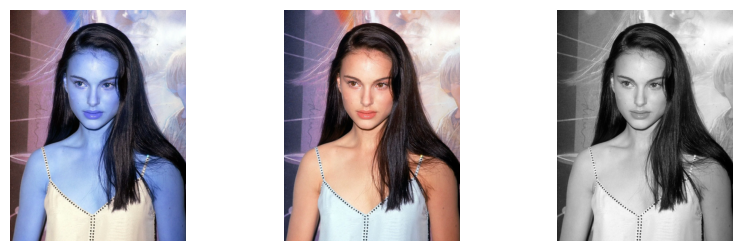

In [3]:
# matplotlib
import cv2
import matplotlib.pyplot as plt

img  = cv2.imread("./data/fig/natal.png", cv2.IMREAD_COLOR) # BGR
imgrgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #RGB
imggray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # GRAY

if img is None:
    print("Image read failed")
    sys.exit()

# cv2.namedWindow("dog", cv2.WINDOW_AUTOSIZE)
# cv2.imshow("dog", img)

# plt.imshow(imgrgb)
# plt.axis("off")
# plt.show()

plt.figure(figsize=(10,3))
plt.subplot(131), plt.imshow(img), plt.axis("off")
plt.subplot(132), plt.imshow(imgrgb), plt.axis("off")
plt.subplot(133), plt.imshow(imggray, cmap = "gray"), plt.axis("off")
plt.show()

# while True:
#     if cv2.waitKey() == 27:
#         break

# cv2.destroyAllWindows()

# 온라인 영상 읽기

In [ ]:
# bytearray도 1바이트 단위의 값을 연속적으로 저장하는 시퀀스 자료형인데, bytes와 차이점은 요소를 변경할 수 있느냐의 차이
# 0~255(0x00~0xFF)까지 정수
bytes(10)
bytes([10, 20, 30, 40, 50])
bytes(b'hello')

b'hello'

In [22]:
from urllib import request

# url = "https://upload.wikimedia.org/wikipedia/ko/thumb/2/24/Lenna.png/220px-Lenna.png"
url = "https://i.namu.wiki/i/m8WyDLzqfPnb9frWwQxGFuZ63AIZBAvnKzpEsQV1LvlvqYc7JWFTLNJa_F6ouZxxzhGFo-eqQeJufYubSVN_oxxItQY0CwcbXFpti9RZe5yi14Z0bWrtk3jQqs1WalIOIXqIvRrIAIHQaXpcOBEq1g.webp"

source = request.urlopen(url).read() # bytes
print(type(source))

<class 'bytes'>


In [4]:
import numpy as np
import cv2

image = np.array(bytearray(source), dtype = np.uint8)
print("image shape = ", image.shape) # (101968,)

# 넘파이 배열 형태의 바이트 데이터로 이루어진 압축된 이미지를 디코딩하여 3채널 컬러(BGR) OpenCV이미지 행렬로 변환하는 구문이다.
# 주로 한글 파일 경로 문제 해결이나 메모리상의 바이너리 데이터를 다툴때 사용한다.
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
cv2.imwrite("Charistmas_download.png", image)

cv2.namedWindow("img", cv2.WINDOW_NORMAL)
cv2.imshow("img", image)

cv2.waitKey()
cv2.destroyAllWindows()


NameError: name 'source' is not defined

# 5. 디렉토리 내 영상읽기

In [ ]:
import cv2

# import glob
# img_files = glob.glob('./data/fig/images/*.jpg')

import os
img_list = os.listdir('./data/fig')
print(img_list)

img_files = [] # list
for i in img_list:
    img_dir = './data/fig/images/' + i # python string
    img_files.append(img_dir)


# print(img_files)

cv2.namedWindow("folder images", cv2.WINDOW_NORMAL)
cv2.setWindowProperty("folder images", cv2.WND_PROP_FULLSCREEN,
                      cv2.WINDOW_FULLSCREEN)

idx = 0
while True:
# for i in img_files:

    img = cv2.imread(img_files[idx], cv2.IMREAD_COLOR)
    cv2.imshow('folder images', img)

    if cv2.waitKey(3000) == 27:
        break

    idx += 1

    if idx >= len(img_files):
        idx = 0

cv2.destroyAllWindows()

['001.jpg', 'images', 'Lenna.png', 'natal.png']


error: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:951: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


: 

# 6.영상의 픽셀값 참조

In [1]:
import cv2

img  = cv2.imread("./data/fig/natal.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()

print("img width = {}, height = {}".format(
    img.shape[1], img.shape[0]))        # img width = 512, height = 512

## 영상 픽셀값
x = 320; y = 240
print("x = {}, y = {} 의 픽셀값".format(x, y))
print(img[240, 320])
# print(img[200:300, 250:400])

# 실행했을 때 이미지 위에 그려진 파랑 박스
# img[H_start : H_end -1 , W_start : W_end -1] = (Blue, Green, Red) : 특정 영역 색상
img[580:750, 250:500] = (125,  0,  66)

cv2.namedWindow("image", cv2.WINDOW_AUTOSIZE)

cv2.imshow("image", img)

while True:
    if cv2.waitKey() == 27:     # 27은 ESC키를 의미함.
        break

cv2.destroyAllWindows()

img width = 585, height = 766
x = 320, y = 240 의 픽셀값
[ 82  93 144]


KeyboardInterrupt: 

In [2]:
import numpy as np

# img1 = np.random.randint(0, 255, (200, 200), np.uint8) # int32
img2 = np.ones((1200, 800, 3), dtype = np.uint8)*255
# img3 = np.zeros((200, 200), np.uint8) + 255
# img4 = np.full((200, 200, 3), (255, 0, 255), np.uint8)

# cv2.imshow("rand int", img1)
cv2.imshow("rand ones", img2)
# cv2.imshow("rand zeros", img3)
# cv2.imshow("rand full", img4)


cv2.waitKey()
cv2.destroyAllWindows()

# 8.영상 복사 (memory copy)

In [ ]:
img = cv2.imread("./data/fig/natal.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()

# img2 = img
# deep copy
img2 = img.copy()

img2[100:150, 200:300] = (255, 0, 0)

cv2.namedWindow("lena", cv2.WINDOW_AUTOSIZE)
cv2.imshow("lena", img)
cv2.imshow("lena copy", img2)


while True:
    if cv2.waitKey() == ord("q"):
        break

cv2.destroyAllWindows()

In [4]:
import cv2
import sys

## 부분영상: 영상 합성에 유리

# 1. 이미지 로드
img = cv2.imread("./data/fig/natal.png", cv2.IMREAD_COLOR)

if img is None:
    print("image read failed")
    sys.exit()

lena_eye = img[240:290, 250:300]

# 2. 레나의 오른쪽 눈(화면상 왼쪽 눈) 영역 슬라이싱 (y축 범위, x축 범위)
# circle(img, center, radius, color[, thickness[, lineType[, shift]]]) -> img
# (267 - 250, 265 - 240) -> (17, 25) 위치에 반지름 15의 원을 그립니다.
cv2.circle(lena_eye, (17, 25), 15, (0, 0, 255), 2)
print(lena_eye.shape)


cv2.namedWindow("lena", cv2.WINDOW_NORMAL)
cv2.imshow("lena", img)
cv2.imshow("lena eye", lena_eye)


while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break

cv2.destroyAllWindows()

(50, 50, 3)


KeyboardInterrupt: 

# 이미지 3개 활용

In [ ]:
import cv2
import numpy as np

## copyTo(): 영상합성
src = cv2.imread("./data/fig/airplane.png", cv2.IMREAD_COLOR)
mask = cv2.imread("./data/fig/mask_plane.png", cv2.IMREAD_GRAYSCALE)
dst = cv2.imread("./data/fig/field.png", cv2.IMREAD_COLOR) 

print(dst.shape)

if src is None or mask is None or dst is None:
    print("Images read failed")
    sys.exit()

# src와 mask는 반드시 같은 크기여야 합니다.
# dst는 src보다 커도 됩니다.   
# mask은  흰색(255)과 검은색(0)으로 되어 있어야만 합니다.
print("src :", src.shape)
print("mask:", mask.shape)
print("dst :", dst.shape)

print("mask min:", mask.min())
print("mask max:", mask.max())


_, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
print("mask unique:", np.unique(mask))
## numpy class
# dst[mask > 0] = src[mask > 0]
cv2.copyTo(src, mask, dst)

cv2.imshow("src", src)
cv2.imshow("mask",mask)
cv2.imshow("dst",dst)

cv2.waitKey()
cv2.destroyAllWindows()


(144, 213, 3)
src : (144, 213, 3)
mask: (144, 213)
dst : (144, 213, 3)
mask min: 0
mask max: 255
mask unique: [  0 255]


In [2]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.line(img, (50, 10), (200, 10), (255, 0, 0), 1)
cv2.line(img, (50, 60), (200, 60), (0, 255, 0), 2)
cv2.line(img, (50, 110), (200, 110), (0, 0, 255), 3)
cv2.line(img, (50, 160), (200, 160), (0, 0, 0), 4)
cv2.line(img, (50, 210), (200, 210), (255, 0, 255), 5)

cv2.imshow('Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

img = np.full((250, 250, 3), 255, dtype=np.uint8)

cv2.rectangle(img, (50, 10), (200, 50), (255, 0, 0))
cv2.rectangle(img, (50, 60), (200, 100), (255, 0, 0), 5)
cv2.rectangle(img, (50, 110), (200, 150), (255, 0, 0), -1)
cv2.rectangle(img, (50, 160), (200, 200), (255, 0, 0), -1)
cv2.rectangle(img, (50, 160), (200, 200), (0, 0, 255), 5)

cv2.imshow('Rectangle', img)
# cv2.waitKey(0)
while True:
    if cv2.waitKey() == 27: # ESC 키 입력 시 종료
        break
cv2.destroyAllWindows()

shape=(300, 400, 3), dtype=uint8
[0,0] BGR: [220 220 220]


C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\

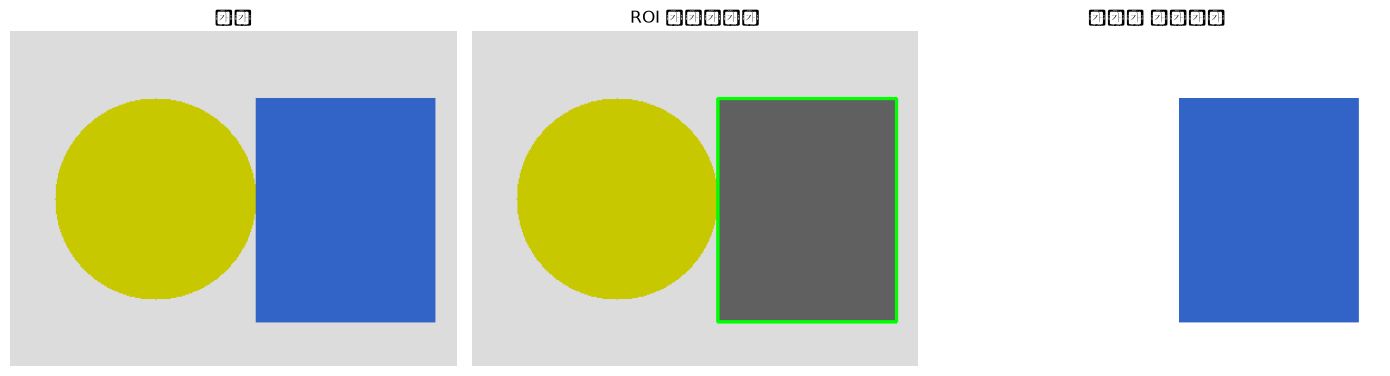

ROI 완료!


In [1]:
""" 픽셀 접근·ROI 선택·조작"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 원본 이미지 생성 (세로 300, 가로 400, 3채널 BGR, uint8 타입)
img = np.zeros((300, 400, 3), dtype=np.uint8)
img[:] = (220, 220, 220)  # 배경을 연한 회색(220, 220, 220)으로 채우기

# 이미지에 도형 추가 (원, 사각형)
cv2.circle(img, (130, 150), 90, (0, 200, 200), -1)  # 노란색 원 (중심: 130,150 / 반지름: 90)
cv2.rectangle(img, (220, 60), (380, 260), (200, 100, 50), -1)  # 파란계열 사각형 (좌상단: 220,60 / 우하단: 380,260)

# 이미지의 기본 정보(크기/채널, 데이터 타입, 특정 위치 픽셀값) 출력
print(f"shape={img.shape}, dtype={img.dtype}")
print(f"[0,0] BGR: {img[0,0]}")  # (0,0) 좌표의 BGR 픽셀값 출력

# 2. ROI(관심 영역) 지정 및 조작
# 사각형 영역(y: 60~260, x: 220~380)을 복사해서 ROI로 추출
roi = img[60:260, 220:380].copy()

# 추출한 ROI를 그레이스케일(1채널)로 변환
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

# 원본(3채널)에 다시 합성하기 위해 그레이스케일 이미지를 3채널 BGR로 재변환
roi_gray_bgr = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2BGR)

# 원본을 복사한 뒤, 해당 사각형 위치에 흑백 변환된 ROI를 덮어쓰기 (합성)
result = img.copy()
result[60:260, 220:380] = roi_gray_bgr

# 처리된 ROI 영역의 테두리를 초록색 선(두께 2)으로 표시
cv2.rectangle(result, (220, 60), (380, 260), (0, 255, 0), 2)

# 3. 조건부 픽셀 마스킹
img_th = img.copy()  # 원본 이미지 복사
gray_t = cv2.cvtColor(img_th, cv2.COLOR_BGR2GRAY)  # 조건판단을 위해 그레이스케일로 변환

# 밝기(그레이스케일 값)가 128 이상인 모든 픽셀을 흰색[255, 255, 255]으로 일괄 변경
img_th[gray_t >= 128] = [255, 255, 255]

# 4. 결과 시각화 및 저장
# 1행 3열 크기(14x5 인치)의 그래프 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 원본, ROI 변환 결과, 조건부 조작 결과를 반복문으로 순회하며 출력
for ax, im, t in zip(axes, [img, result, img_th], ["원본", "ROI 그레이변환", "조건부 픽셀조작"]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환
    ax.set_title(t)  # 각 서브플롯의 제목 설정
    ax.axis("off")  # 눈금 및 좌표축 숨기기

plt.tight_layout()  # 플롯 간 여백 자동 정돈
plt.savefig("roi_demo.png", dpi=100, bbox_inches="tight")  # 이미지 파일 저장 (100 DPI)
plt.show()  # 완성된 결과창 표시

print("ROI 완료!")

shape=(300, 400, 3), dtype=uint8
[0,0] BGR: [220 220 220]


C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\Temp\ipykernel_10984\3436099510.py:52: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # 플롯 간 여백 자동 정돈
C:\Users\playdata\AppData\Local\

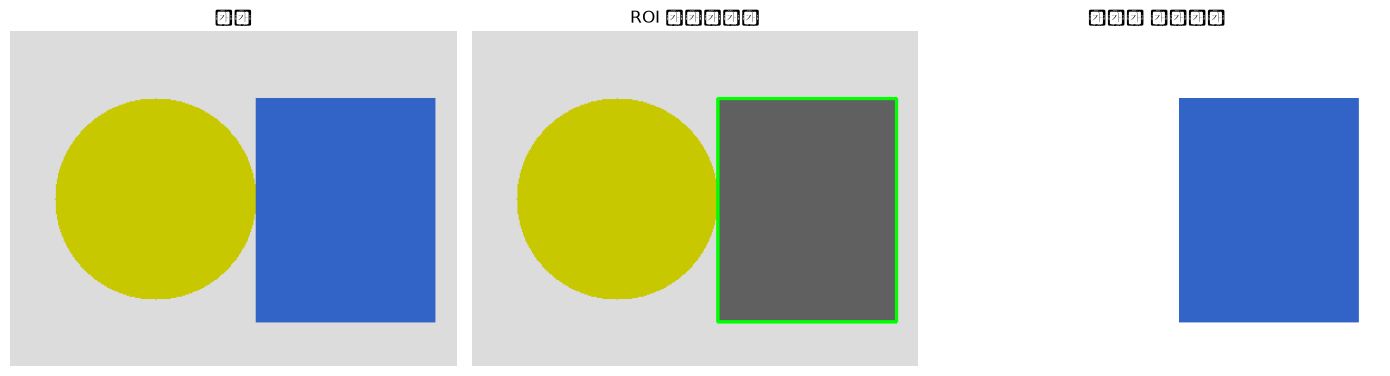

ROI 완료!


In [2]:
""" 픽셀 접근·ROI 선택·조작"""
import cv2  # 이미지 처리를 위한 OpenCV 라이브러리 불러오기
import numpy as np  # 행렬 연산 및 배열 생성을 위한 NumPy 불러오기
import matplotlib.pyplot as plt  # 시각화를 위한 Matplotlib 불러오기

# 1. 원본 이미지 생성 (세로 300, 가로 400, 3채널 BGR, uint8 타입)
img = np.zeros((300, 400, 3), dtype=np.uint8)
img[:] = (220, 220, 220)  # 배경을 연한 회색(220, 220, 220)으로 채우기

# 이미지에 도형 추가 (원, 사각형)
cv2.circle(img, (130, 150), 90, (0, 200, 200), -1)  # 노란색 원 (중심: 130,150 / 반지름: 90)
cv2.rectangle(img, (220, 60), (380, 260), (200, 100, 50), -1)  # 파란계열 사각형 (좌상단: 220,60 / 우하단: 380,260)

# 이미지의 기본 정보(크기/채널, 데이터 타입, 특정 위치 픽셀값) 출력
print(f"shape={img.shape}, dtype={img.dtype}")
print(f"[0,0] BGR: {img[0,0]}")  # (0,0) 좌표의 BGR 픽셀값 출력

# 2. ROI(관심 영역) 지정 및 조작
# 사각형 영역(y: 60~260, x: 220~380)을 복사해서 ROI로 추출
roi = img[60:260, 220:380].copy()

# 추출한 ROI를 그레이스케일(1채널)로 변환
roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

# 원본(3채널)에 다시 합성하기 위해 그레이스케일 이미지를 3채널 BGR로 재변환
roi_gray_bgr = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2BGR)

# 원본을 복사한 뒤, 해당 사각형 위치에 흑백 변환된 ROI를 덮어쓰기 (합성)
result = img.copy()
result[60:260, 220:380] = roi_gray_bgr

# 처리된 ROI 영역의 테두리를 초록색 선(두께 2)으로 표시
cv2.rectangle(result, (220, 60), (380, 260), (0, 255, 0), 2)

# 3. 조건부 픽셀 마스킹
img_th = img.copy()  # 원본 이미지 복사
gray_t = cv2.cvtColor(img_th, cv2.COLOR_BGR2GRAY)  # 조건판단을 위해 그레이스케일로 변환

# 밝기(그레이스케일 값)가 128 이상인 모든 픽셀을 흰색[255, 255, 255]으로 일괄 변경
img_th[gray_t >= 128] = [255, 255, 255]

# 4. 결과 시각화 및 저장
# 1행 3열 크기(14x5 인치)의 그래프 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 원본, ROI 변환 결과, 조건부 조작 결과를 반복문으로 순회하며 출력
for ax, im, t in zip(axes, [img, result, img_th], ["원본", "ROI 그레이변환", "조건부 픽셀조작"]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))  # Matplotlib에 맞게 BGR -> RGB 변환
    ax.set_title(t)  # 각 서브플롯의 제목 설정
    ax.axis("off")  # 눈금 및 좌표축 숨기기

plt.tight_layout()  # 플롯 간 여백 자동 정돈
plt.savefig("roi_demo.png", dpi=100, bbox_inches="tight")  # 이미지 파일 저장 (100 DPI)
plt.show()  # 완성된 결과창 표시

print("ROI 완료!")